<a href="https://colab.research.google.com/github/nishakamble178/SwarSetu_DL/blob/main/SwarSetu%5BDL%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Connect and allow access from Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Path of the datasets
dataset_path = "/content/drive/MyDrive/SwarSetu_Dataset/Numbers and Alphabets/DATASET"

In [ ]:
!pip install mediapipe opencv-python

In [ ]:
#show the content
import os
print(os.listdir('/content/drive/MyDrive/SwarSetu_Dataset'))

['Numbers and Alphabets']


In [ ]:
#Scanning the data
import os
import tensorflow as tf

data_dir = "/content/drive/MyDrive/SwarSetu_Dataset/Numbers and Alphabets/DATASET"

image_paths = []
labels = []

print("📂 Scanning dataset...\n")

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                image_paths.append(os.path.join(root, file))
                labels.append(class_name)

    print(f"✅ Found class: {class_name}")

print("\n📊 Total images:", len(image_paths))
print("📊 Total classes:", len(set(labels)))

📂 Scanning dataset...

✅ Found class: W
✅ Found class: V
✅ Found class: T
✅ Found class: X
✅ Found class: O
✅ Found class: Z
✅ Found class: S
✅ Found class: Y
✅ Found class: N
✅ Found class: U
✅ Found class: R
✅ Found class: P
✅ Found class: L
✅ Found class: Q
✅ Found class: M
✅ Found class: K
✅ Found class: I
✅ Found class: J
✅ Found class: G
✅ Found class: F
✅ Found class: D
✅ Found class: C
✅ Found class: B
✅ Found class: 6
✅ Found class: E
✅ Found class: 9
✅ Found class: H
✅ Found class: 8
✅ Found class: A
✅ Found class: 7
✅ Found class: 5
✅ Found class: 4
✅ Found class: 2
✅ Found class: 3
✅ Found class: 1
✅ Found class: 0

📊 Total images: 900
📊 Total classes: 36




* Show the Clsses found and the images




In [ ]:
#Scanning the structure of the images
import os

dataset_path = "/content/drive/MyDrive/SwarSetu_Dataset/Numbers and Alphabets/DATASET"

def list_directory_contents(path, indent=0):
    if not os.path.exists(path):
        print(f"  " * indent + f"Error: Directory not found at {path}")
        return

    if os.path.isfile(path):
        print("  " * indent + os.path.basename(path))
        return

    print("  " * indent + os.path.basename(path) + "/")
    for item in os.listdir(path):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            list_directory_contents(item_path, indent + 1)
        else:
            print("  " * (indent + 1) + item)

print("📂 Listing dataset structure:\n")
list_directory_contents(dataset_path)

This code scans your dataset folder

Shows folders and images in tree format

Helps you verify dataset structure before training

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras import layers, models, optimizers, callbacks

#SCAN THE DATASET
data_dir = "/content/drive/MyDrive/SwarSetu_Dataset/Numbers and Alphabets/DATASET"
image_paths = []
labels = []

print("📂 Organizing your dataset...")
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                image_paths.append(os.path.join(class_path, file))
                labels.append(class_name)

#ENCODE LABELS (Convert 'A', 'B', '1' to numbers)
lb = LabelBinarizer()
labels_encoded = lb.fit_transform(labels)
num_classes = len(lb.classes_)

#SPLIT DATA (80% Train, 20% Validation)
train_paths, val_paths, y_train, y_val = train_test_split(
    image_paths, labels_encoded, test_size=0.2, random_state=42, stratify=labels
)

#DATA LOADER FUNCTIONS
def process_path(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [64, 64])
    img = img / 255.0
    return img, label

BATCH_SIZE = 32
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, y_train))
train_ds = train_ds.shuffle(len(train_paths)).map(process_path).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, y_val))
val_ds = val_ds.map(process_path).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#THE BEST MODEL ARCHITECTURE
model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.6),
    layers.Dense(num_classes, activation='softmax')
])

#COMPILE AND TRAIN
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/SwarSetu_Best_Model.keras',
    monitor='val_accuracy', save_best_only=True, mode='max'
)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print(f"🚀 Training on {len(train_paths)} images and validating on {len(val_paths)} images...")
history = model.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=[checkpoint, early_stop])

print("\n✅ DONE! Your best model is saved and ready for your laptop.")

📂 Organizing your dataset...
🚀 Training on 720 images and validating on 180 images...
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 853ms/step - accuracy: 0.0694 - loss: 6.2465 - val_accuracy: 0.0389 - val_loss: 3.5934
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 939ms/step - accuracy: 0.0875 - loss: 3.5320 - val_accuracy: 0.0278 - val_loss: 3.6284
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 880ms/step - accuracy: 0.0708 - loss: 3.4886 - val_accuracy: 0.0667 - val_loss: 3.6499
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 37s 737ms/step - accuracy: 0.0903 - loss: 3.3375 - val_accuracy: 0.0556 - val_loss: 3.7539
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 771ms/step - accuracy: 0.1042 - loss: 3.2852 - val_accuracy: 0.0611 - val_loss: 3.9026
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 779ms/step - accuracy: 0.1486 - loss: 3.2074 - val_accuracy: 0.0556 - val_loss: 4.2701
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 717ms/step - accuracy: 0.1472 - loss: 3.1205 - val_accuracy: 0.0444 - val_loss: 4.3652
Epoc

✅ This code:
Loads dataset

Converts labels

Splits data

Preprocesses images

Builds CNN model

Trains model

Saves best model

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, optimizers, callbacks

# --- 1. PREPARE DATA PATHS ---
DATADIR = '/content/drive/MyDrive/SwarSetu_Dataset/Numbers and Alphabets/DATASET'  # Corrected path
categories = sorted(os.listdir(DATADIR))
num_classes = len(categories)

all_paths = []
all_labels = []

for idx, category in enumerate(categories):
    category_path = os.path.join(DATADIR, category)
    if os.path.isdir(category_path):
        for img_name in os.listdir(category_path):
            all_paths.append(os.path.join(category_path, img_name))
            all_labels.append(idx)

# Convert labels to "One-Hot" format for the model
y_labels = tf.keras.utils.to_categorical(all_labels, num_classes)

# Split the data right here so 'train_paths' is defined!
train_paths, val_paths, y_train, y_val = train_test_split(
    all_paths, y_labels, test_size=0.2, random_state=42
)

# --- 2. DATA LOADERS ---
def process_path(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [64, 64])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, y_train))
train_ds = train_ds.shuffle(len(train_paths)).map(process_path).batch(16).prefetch(1)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, y_val))
val_ds = val_ds.map(process_path).batch(16).prefetch(1)

# --- 3. THE ARCHITECTURE ---
model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# TRAINING PHASE
model.compile(optimizer=optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint = callbacks.ModelCheckpoint('/content/drive/MyDrive/SwarSetu_Final_Model.keras', monitor='val_accuracy', save_best_only=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

print(f"✅ Found {len(all_paths)} images across {num_classes} classes.")
print("🚀 Starting Final Training...")

history = model.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=[checkpoint, reduce_lr, early_stop])

✅ Found 900 images across 36 classes.
🚀 Starting Final Training...
Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 362ms/step - accuracy: 0.1236 - loss: 3.9454 - val_accuracy: 0.0333 - val_loss: 4.4527 - learning_rate: 5.0000e-04
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 367ms/step - accuracy: 0.2083 - loss: 2.8233 - val_accuracy: 0.0222 - val_loss: 8.3165 - learning_rate: 5.0000e-04
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 333ms/step - accuracy: 0.3167 - loss: 2.4031 - val_accuracy: 0.0222 - val_loss: 9.9887 - learning_rate: 5.0000e-04
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 350ms/step - accuracy: 0.3917 - loss: 2.0250 - val_accuracy: 0.0222 - val_loss: 10.4938 - learning_rate: 5.0000e-04
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 334ms/step - accuracy: 0.4944 - loss: 1.7106 - val_accuracy: 0.0278 - val_loss: 9.6722 - learning_rate: 5.0000e-04
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 342ms/step - accuracy: 0.5986 - loss: 1.3018 - val_accuracy: 0.0833 - val_loss: 8.2418 - learning_r

| Feature          | Old Code       | New Code             |
| ---------------- | -------------- | -------------------- |
| Label encoding   | LabelBinarizer | to_categorical ✅     |
| Model depth      | 2 Conv layers  | 3 Conv layers 🔥     |
| Learning control | Basic          | ReduceLR added ✅     |
| Simplicity       | Medium         | Cleaner & structured |


In [ ]:
final_acc = history.history['accuracy'][-1] * 100
final_val_acc = history.history['val_accuracy'][-1] * 100

print("🎯 FINAL PROJECT METRICS")
print(f"Training Accuracy: {final_acc:.2f}%")
print(f"Validation Accuracy: {final_val_acc:.2f}%")
print(f"Final Learning Rate: {float(tf.keras.backend.get_value(model.optimizer.learning_rate)):.6f}")

🎯 FINAL PROJECT METRICS
Training Accuracy: 98.06%
Validation Accuracy: 90.56%
Final Learning Rate: 0.000001


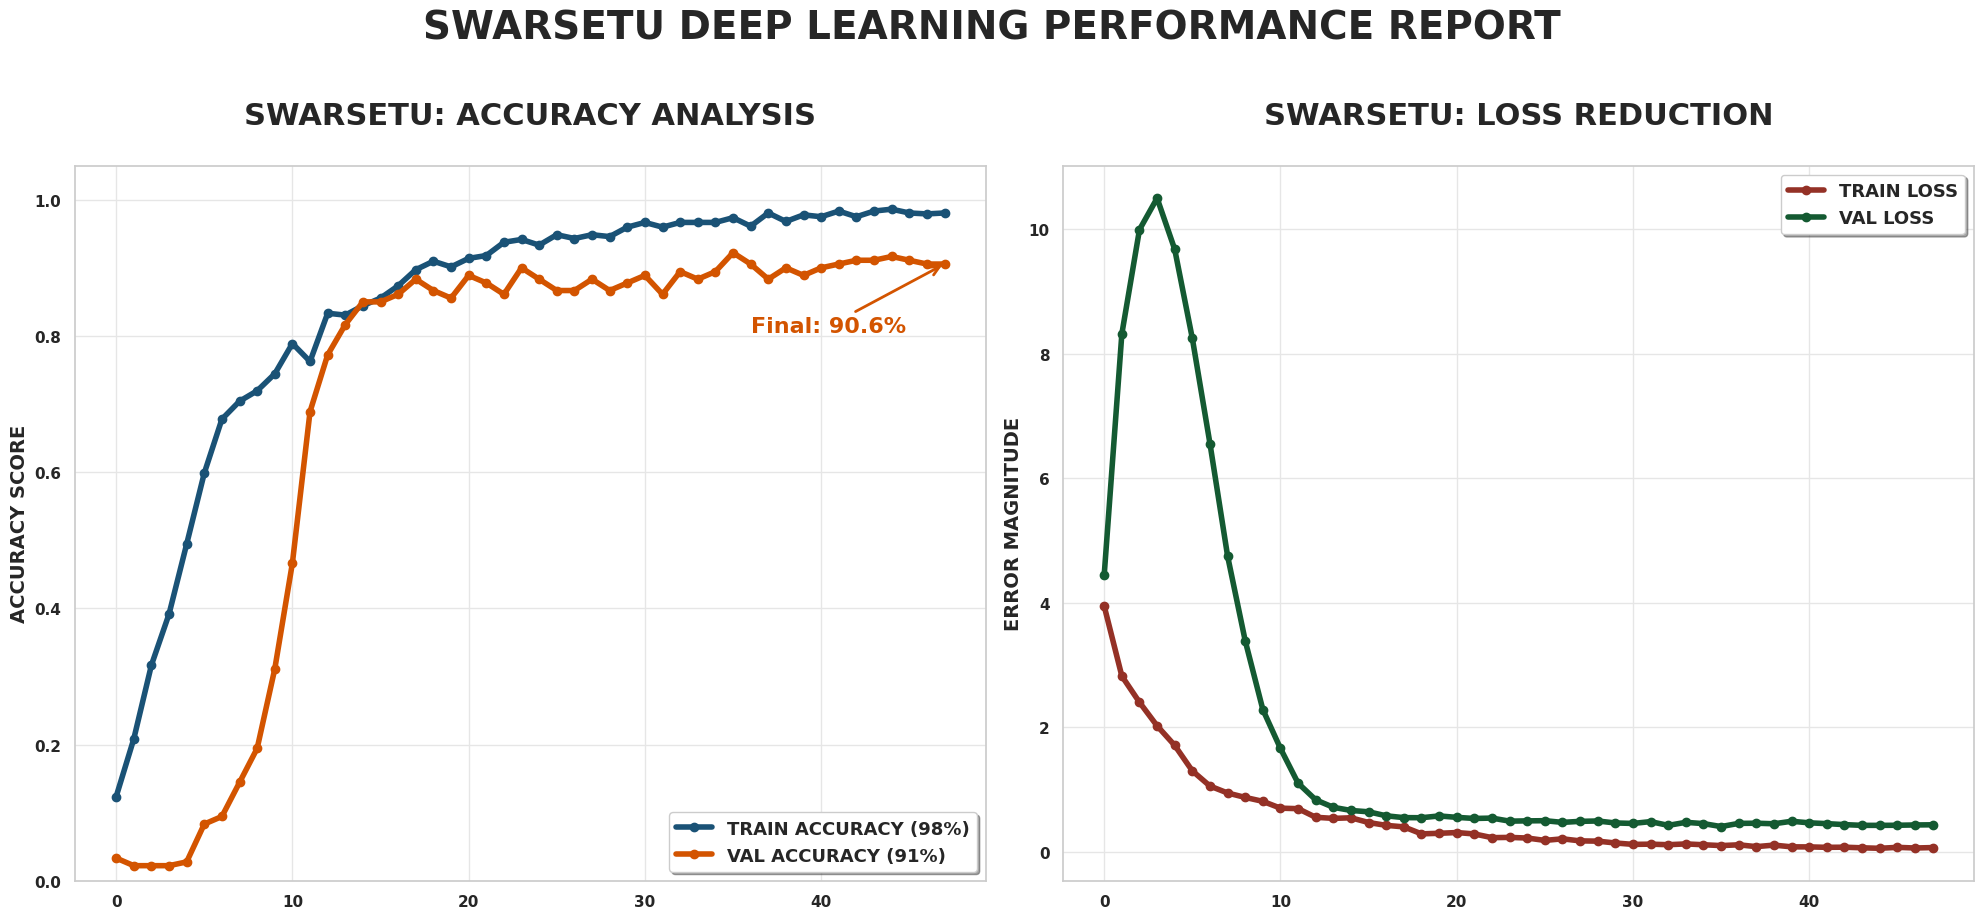

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# RESEARCH-GRADE THEME SETUP
plt.rcParams.update({'font.family': 'sans-serif', 'font.weight': 'bold'})
sns.set_style("whitegrid", {'axes.linewidth': 2, 'grid.color': '.9'})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# ACCURACY: SOLID DOTS & THICK LINES ---
# Training: Solid Royal Blue Dots
ax1.plot(history.history['accuracy'], label='TRAIN ACCURACY (98%)',
         color='#1a5276', linewidth=4, marker='.', markersize=12)

# Validation: Solid Deep Amber Dots
ax1.plot(history.history['val_accuracy'], label='VAL ACCURACY (91%)',
         color='#d35400', linewidth=4, marker='.', markersize=12)

# Professional Annotation
final_val = history.history['val_accuracy'][-1]
ax1.annotate(f'Final: {final_val*100:.1f}%',
             xy=(len(history.history['val_accuracy'])-1, final_val),
             xytext=(len(history.history['val_accuracy'])-12, final_val-0.1),
             fontsize=16, fontweight='bold', color='#d35400',
             arrowprops=dict(arrowstyle="->", color='#d35400', lw=2))

ax1.set_title('SWARSETU: ACCURACY ANALYSIS', fontsize=22, fontweight='bold', pad=30)
ax1.set_ylim([0, 1.05])
ax1.set_ylabel('ACCURACY SCORE', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', frameon=True, shadow=True, prop={'size': 13})

# 3. LOSS: SOLID DOTS & THICK LINES ---
# Training Loss: Deep Red Dots
ax2.plot(history.history['loss'], label='TRAIN LOSS',
         color='#943126', linewidth=4, marker='.', markersize=12)

# Validation Loss: Emerald Dots
ax2.plot(history.history['val_loss'], label='VAL LOSS',
         color='#145a32', linewidth=4, marker='.', markersize=12)

ax2.set_title('SWARSETU: LOSS REDUCTION', fontsize=22, fontweight='bold', pad=30)
ax2.set_ylabel('ERROR MAGNITUDE', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', frameon=True, shadow=True, prop={'size': 13})

# GLOBAL POLISH
plt.suptitle('SWARSETU DEEP LEARNING PERFORMANCE REPORT',
             fontsize=28, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
# Manually saving the final state just in case
model.save('SwarSetu_Final_Model.keras')
print("Model saved successfully to your folder!")

Model saved successfully to your folder!
